In [1]:
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
from sklearn.datasets import fetch_california_housing
housing=fetch_california_housing()


In [5]:
X=housing.data
y=housing.target 

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
lr=LinearRegression()
lr.fit(X_train,y_train)
test_pred=lr.predict(X_test)
train_pred=lr.predict(X_train)
print("Train RMSE:",
      mean_squared_error(y_train, train_pred)**0.5)

print("Test RMSE:",
      mean_squared_error(y_test, test_pred)**0.5)

Train RMSE: 0.7196757085831575
Test RMSE: 0.7455813830127747


### bias is high as it is faraway from the actual value but variance is low model is underfitted

In [10]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)

print("Train RMSE:",
      mean_squared_error(y_train, train_pred)**0.5)

print("Test RMSE:",
      mean_squared_error(y_test, test_pred)**0.5)

Train RMSE: 3.218325866275131e-16
Test RMSE: 0.7037294974840077


### Train error almost 0 but high test error so model is overfitted bias low but variance high

In [11]:
depths = [1,2,3,5,8,12,20,None]
results = []

for depth in depths:

    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train,y_train)

    train_rmse = mean_squared_error(
        y_train,
        model.predict(X_train)
    )**0.5

    test_rmse = mean_squared_error(
        y_test,
        model.predict(X_test)
    )**0.5

    results.append([depth,train_rmse,test_rmse])

In [13]:
pd.DataFrame(results,columns=["Depth","Train RMSE","Test RMSE"])

,Depth,Train RMSE,Test RMSE
0,1.0,9.555229e-01,0.971666
1,2.0,8.558590e-01,0.868483
2,3.0,7.859567e-01,0.801505
3,5.0,6.959478e-01,0.724234
4,8.0,5.662111e-01,0.649650
5,12.0,3.672277e-01,0.659083
6,20.0,7.567759e-02,0.699356
7,NaN,3.218326e-16,0.703729


#### Depth 1–3: Bias dominates. The model is too simple to capture the underlying relationship.
#### Depth 8: Bias has been reduced without variance becoming too large. This is the best balance.
#### Depth 20 / None: Bias is extremely low (training error near zero), but variance dominates because the model has become too sensitive to the training data.

In [31]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, val_scores = learning_curve(
    DecisionTreeRegressor(max_depth=8,random_state=42),
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)
print(train_sizes)
print(train_scores)
print("*"*50)
print(val_scores)
train_mean = -train_scores.mean(axis=1)
val_mean = -val_scores.mean(axis=1)
print("*"*50)
print(train_mean)
print(val_mean)

[ 1651  5366  9081 12796 16512]
[[-0.35488621 -0.28507072 -0.28507072 -0.28507072 -0.28507072]
 [-0.4665874  -0.38919856 -0.38933843 -0.38933843 -0.38933843]
 [-0.49844222 -0.446068   -0.42941042 -0.44814571 -0.44814571]
 [-0.55351166 -0.54071997 -0.52670641 -0.50064151 -0.48031088]
 [-0.56157075 -0.54753193 -0.56506329 -0.53927767 -0.53270114]]
**************************************************
[[-2.03490645 -0.93586624 -1.00387587 -0.93621101 -0.90673813]
 [-0.87486958 -0.70961988 -1.33183944 -1.12953257 -0.86229565]
 [-0.8781039  -0.68488112 -0.83733092 -1.19701779 -0.87626149]
 [-0.91497125 -0.76075698 -0.77426398 -0.83089416 -0.79362054]
 [-0.79111018 -0.73496885 -0.73554207 -0.84643205 -0.78548872]]
**************************************************
[0.29903382 0.40476025 0.45404241 0.52037808 0.54922896]
[1.16351954 0.98163142 0.89471904 0.81490138 0.77870837]


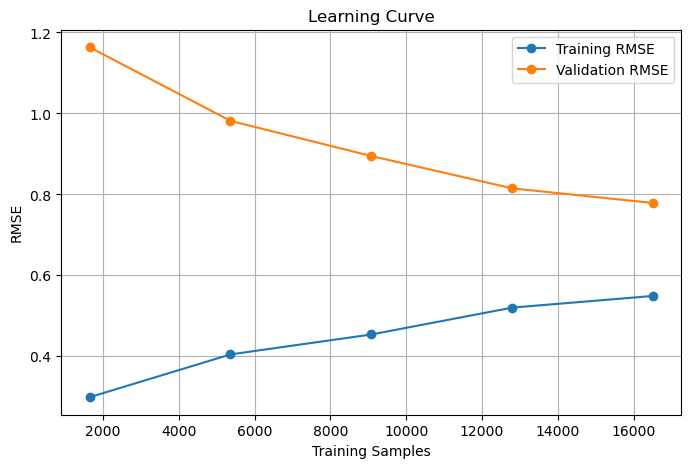

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, marker='o', label='Training RMSE')
plt.plot(train_sizes, val_mean, marker='o', label='Validation RMSE')

plt.xlabel("Training Samples")
plt.ylabel("RMSE")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)

plt.show()

In [32]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor
import numpy as np

model = DecisionTreeRegressor(max_depth=8, random_state=42)

scores = cross_val_score(
    estimator=model,
    X=X,
    y=y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse = -scores

print("RMSE for each fold:")
print(rmse)

print("\nAverage RMSE:", np.mean(rmse))
print("Standard Deviation:", np.std(rmse))

RMSE for each fold:
[0.79111018 0.73496885 0.73554207 0.84643205 0.78548872]

Average RMSE: 0.778708374661773
Standard Deviation: 0.04138296801551325


Validation Curve Results
----------------------------------------------------------------------
Depth     Train RMSE     Validation RMSE     
1         0.9566         0.9764              
2         0.8561         0.8763              
3         0.7842         0.8287              
5         0.6858         0.8141              
8         0.5492         0.7787              
12        0.3522         0.8469              
20        0.0717         0.8941              


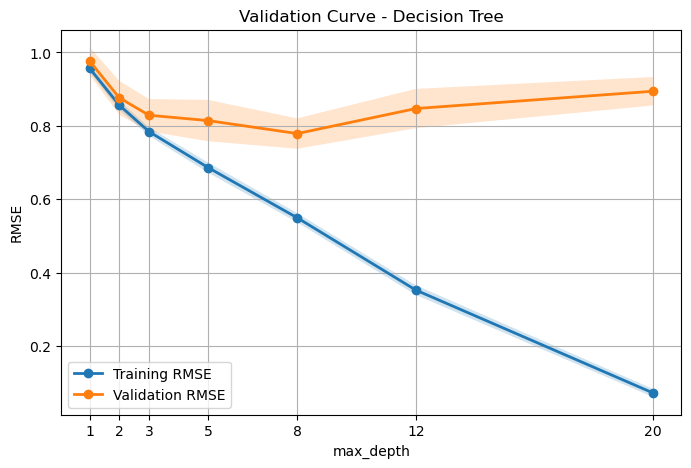

In [33]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import validation_curve

# Define the model
model = DecisionTreeRegressor(random_state=42)

# Hyperparameter values to test
depths = [1, 2, 3, 5, 8, 12, 20]

# Compute validation curve
train_scores, val_scores = validation_curve(
    estimator=model,
    X=X,
    y=y,
    param_name="max_depth",
    param_range=depths,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

# Convert negative RMSE to positive RMSE
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = -np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Print Results
print("Validation Curve Results")
print("-" * 70)
print(f"{'Depth':<10}{'Train RMSE':<15}{'Validation RMSE':<20}")

for depth, train, val in zip(depths, train_mean, val_mean):
    print(f"{depth:<10}{train:<15.4f}{val:<20.4f}")

# Plot Validation Curve
plt.figure(figsize=(8,5))

plt.plot(depths, train_mean,
         marker='o',
         linewidth=2,
         label='Training RMSE')

plt.plot(depths, val_mean,
         marker='o',
         linewidth=2,
         label='Validation RMSE')

# Optional: show variability across folds
plt.fill_between(
    depths,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    depths,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel("max_depth")
plt.ylabel("RMSE")
plt.title("Validation Curve - Decision Tree")
plt.xticks(depths)
plt.grid(True)
plt.legend()

plt.show()